In [33]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [34]:
bank = pd.read_csv('/home/aiden/projects/ML/banking/dataset/bank-additional-full.csv', sep=';')

In [35]:
bank.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [36]:
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [37]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [38]:
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [39]:
for i in ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]:
    print(bank[i].value_counts(normalize=True)*100)
    print("\n")

job
admin.           25.303486
blue-collar      22.467709
technician       16.371273
services          9.636302
management        7.099155
retired           4.175974
entrepreneur      3.535010
self-employed     3.450034
housemaid         2.573565
unemployed        2.461882
student           2.124405
unknown           0.801204
Name: proportion, dtype: float64


marital
married     60.522482
single      28.085850
divorced    11.197436
unknown      0.194231
Name: proportion, dtype: float64


education
university.degree      29.542585
high.school            23.101389
basic.9y               14.676605
professional.course    12.729436
basic.4y               10.138875
basic.6y                5.564728
unknown                 4.202680
illiterate              0.043702
Name: proportion, dtype: float64


default
no         79.120132
unknown    20.872584
yes         0.007284
Name: proportion, dtype: float64


housing
yes        52.384190
no         45.212198
unknown     2.403613
Name: proportion, dt

In [40]:
test= bank[bank["job"].isin(["admin.","blue-collar","technician"])]
tes2=bank[bank["job"].isin(["unknown","student","unemployed"])]
for i in ["job","y"]:
    print(test[i].value_counts(normalize=True)*100)
    print("\n")

for i in ["job","y"]:
    print(tes2[i].value_counts(normalize=True)*100)
    print("\n")

job
admin.         39.448881
blue-collar    35.027821
technician     25.523298
Name: proportion, dtype: float64


y
no     89.704379
yes    10.295621
Name: proportion, dtype: float64


job
unemployed    45.696260
student       39.432177
unknown       14.871564
Name: proportion, dtype: float64


y
no     79.450203
yes    20.549797
Name: proportion, dtype: float64




In [41]:
bank["pdays"].value_counts(normalize=True)

pdays
999    0.963217
3      0.010658
6      0.010003
4      0.002865
9      0.001554
2      0.001481
7      0.001457
12     0.001408
10     0.001263
5      0.001117
13     0.000874
11     0.000680
1      0.000631
15     0.000583
14     0.000486
8      0.000437
0      0.000364
16     0.000267
17     0.000194
18     0.000170
22     0.000073
19     0.000073
21     0.000049
25     0.000024
26     0.000024
27     0.000024
20     0.000024
Name: proportion, dtype: float64

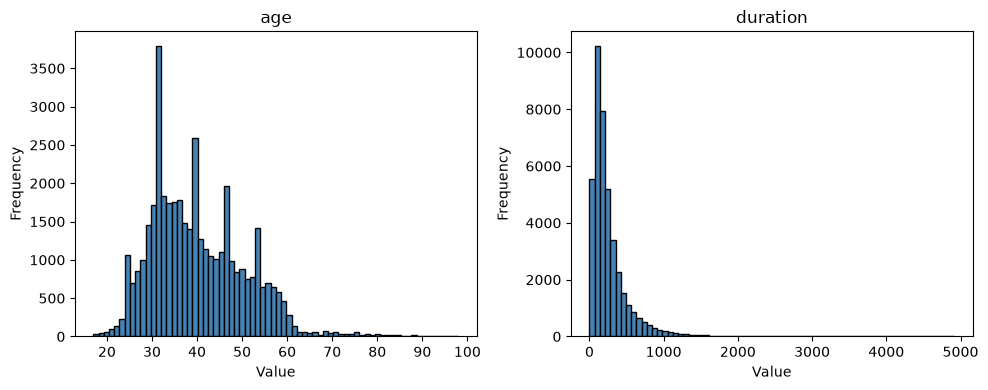

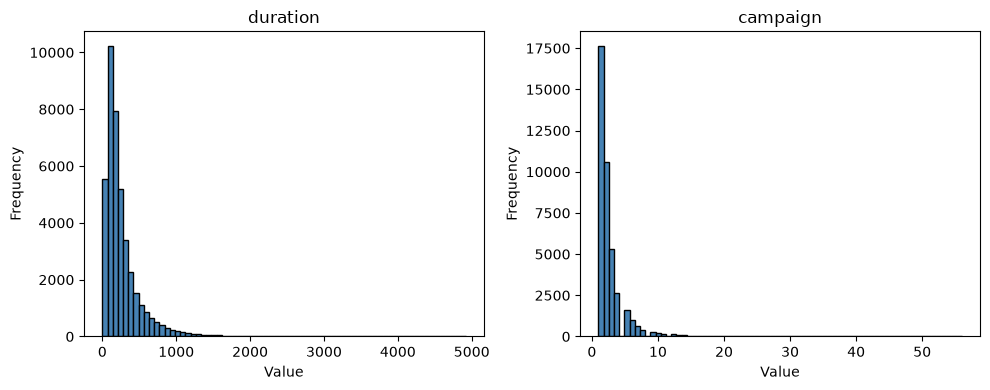

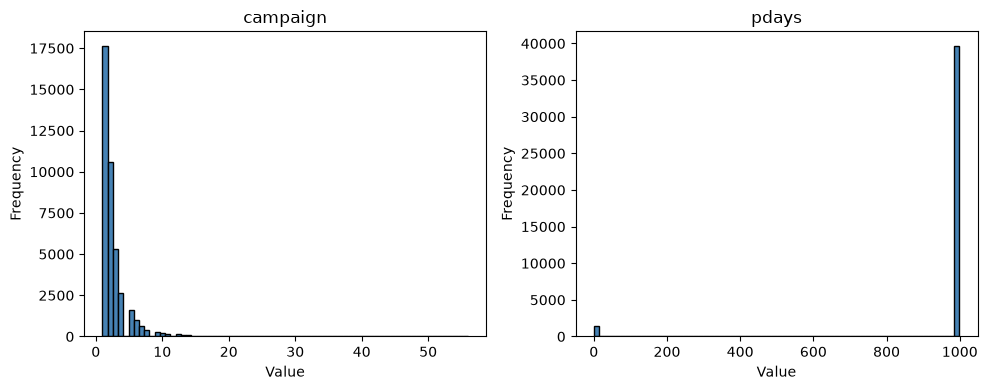

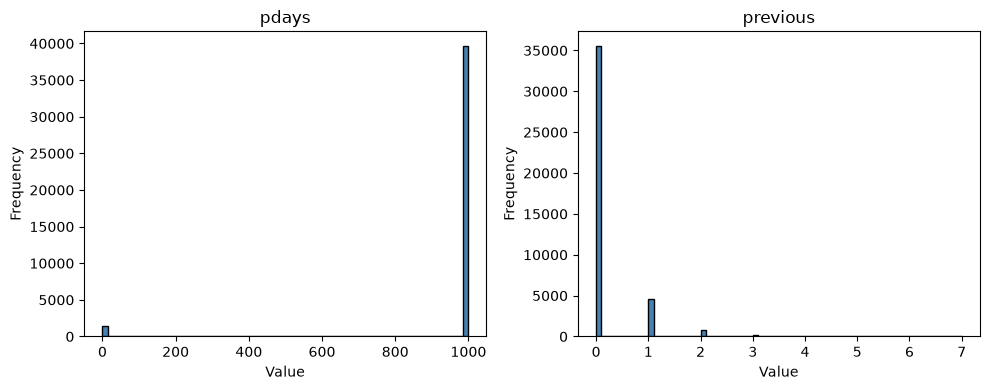

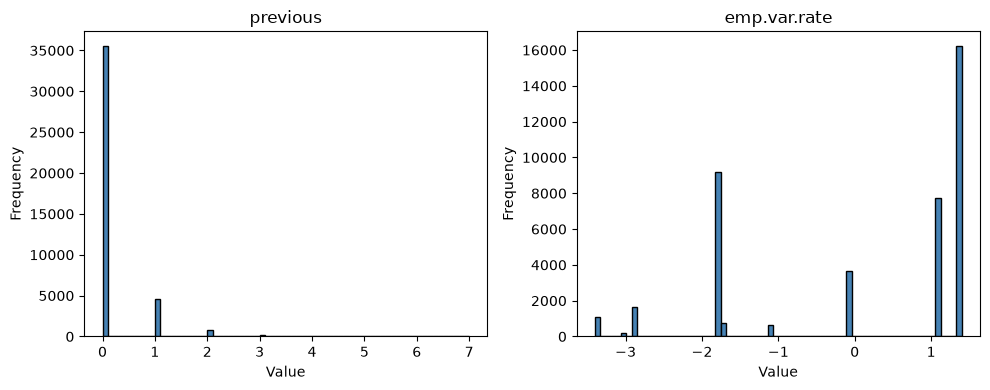

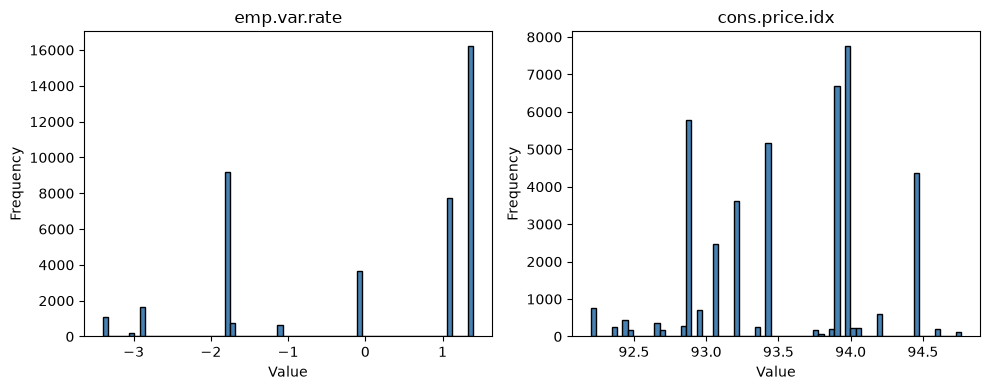

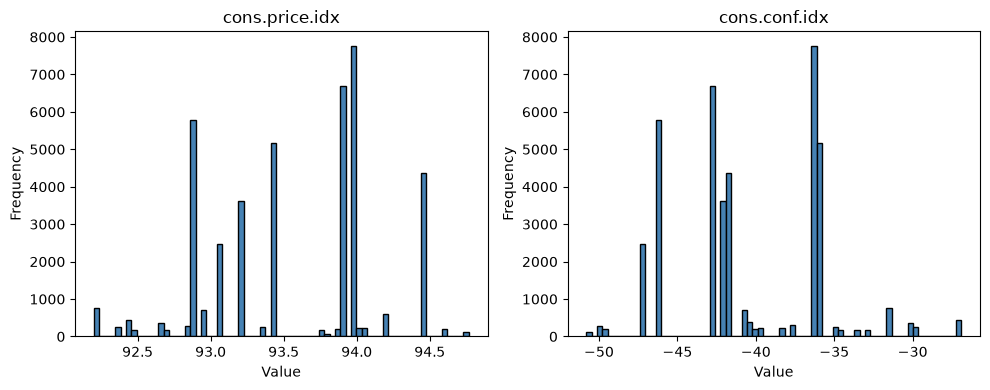

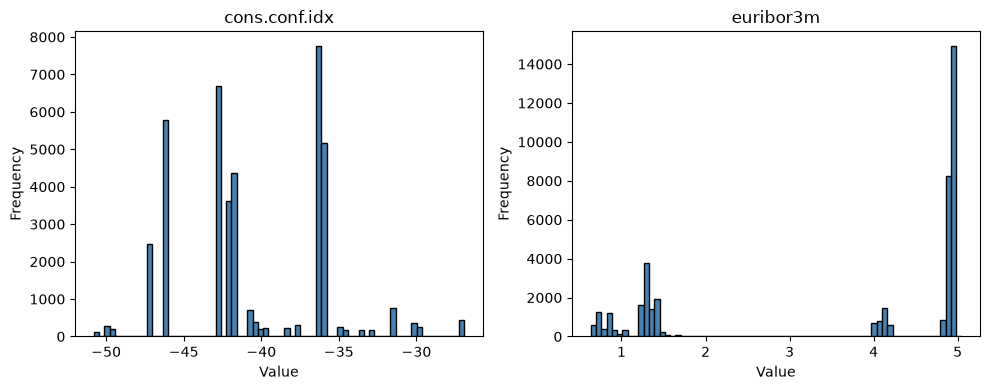

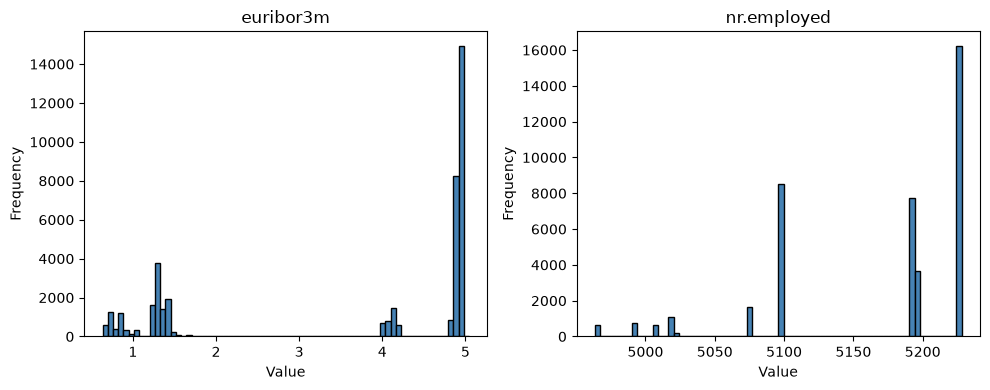

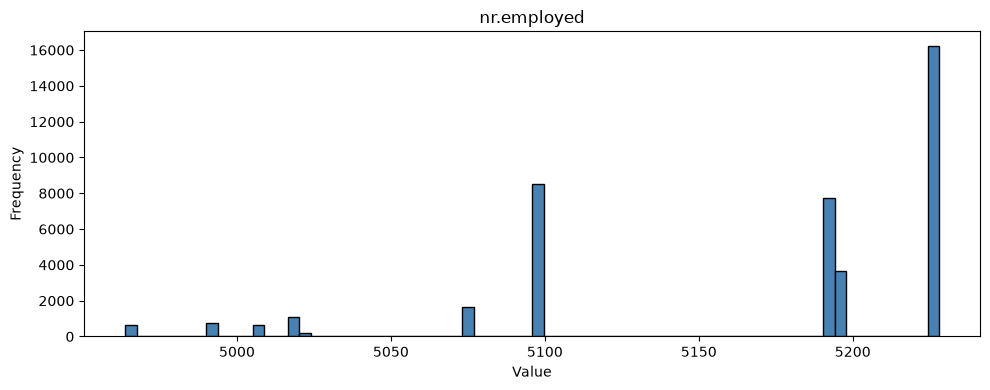

In [42]:
num_cols = bank.select_dtypes(include=[np.number]).columns.tolist()

# Plot 2 histograms side-by-side per window
for i in range(0, len(num_cols)):
    batch = num_cols[i:i+2]
    fig, axes = plt.subplots(1, len(batch), figsize=(10, 4))
    
    if len(batch) == 1:
        axes = [axes]
        
    for ax, col in zip(axes, batch):
        ax.hist(bank[col], bins=70, color="steelblue", edgecolor="black")
        ax.set_title(col)
        ax.set_xlabel("Value")
        ax.set_ylabel("Frequency")
        
    plt.tight_layout()
    plt.show()

In [43]:
bank["pdays"].value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [44]:
def categorize_pdays(col):
    if col==999:
        return "never-contacted"
    elif col<=7:
        return "recent"
    elif col<=14:
        return "mid"
    elif col<999:
        return "late"
bank["pdays_cat"]=bank["pdays"].apply(categorize_pdays).astype("category")
bank["pdays_cat"].value_counts()

pdays_cat
never-contacted    39673
recent              1177
mid                  276
late                  62
Name: count, dtype: int64

In [45]:
bank.drop("pdays",axis=1,inplace=True)
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             41188 non-null  str     
 2   marital         41188 non-null  str     
 3   education       41188 non-null  str     
 4   default         41188 non-null  str     
 5   housing         41188 non-null  str     
 6   loan            41188 non-null  str     
 7   contact         41188 non-null  str     
 8   month           41188 non-null  str     
 9   day_of_week     41188 non-null  str     
 10  duration        41188 non-null  int64   
 11  campaign        41188 non-null  int64   
 12  previous        41188 non-null  int64   
 13  poutcome        41188 non-null  str     
 14  emp.var.rate    41188 non-null  float64 
 15  cons.price.idx  41188 non-null  float64 
 16  cons.conf.idx   41188 non-null  float64 
 17  euribor3m       41188 n

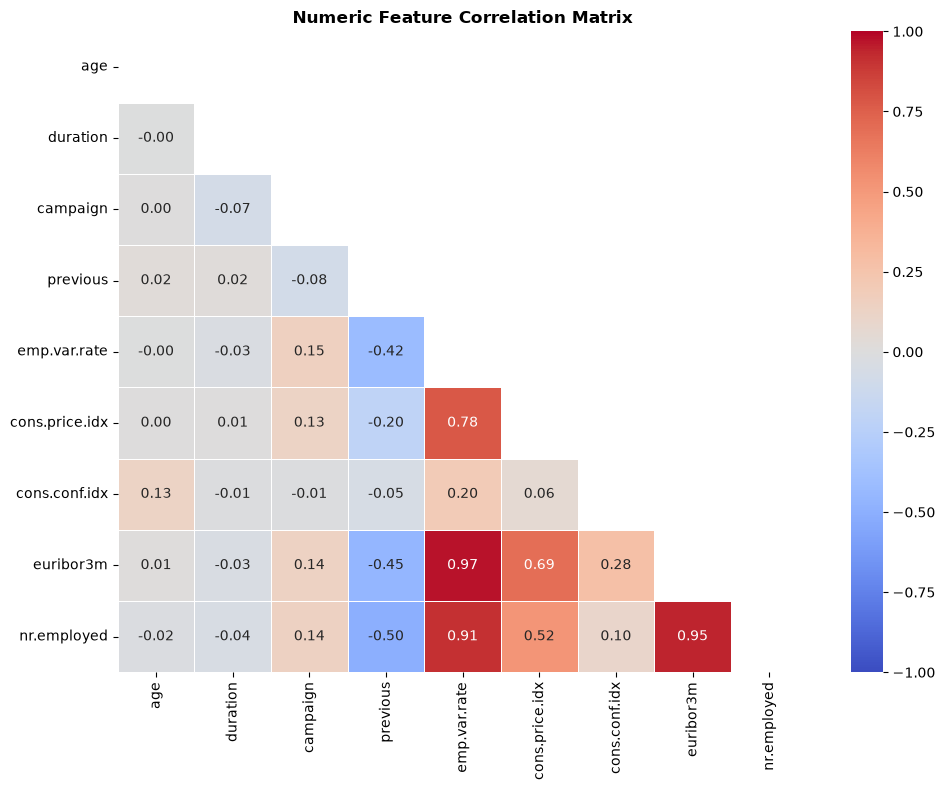

In [46]:

# Select all numeric features
num_cols = bank.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = bank[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)
plt.title("Numeric Feature Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()



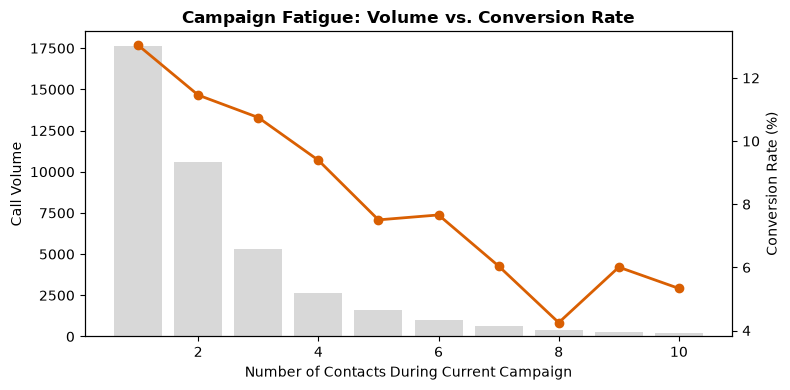

In [47]:
''' 
plotting relationship 
bw number of calls and cpnversion rate
'''

campaign_stats = (
    bank[bank["campaign"] <= 10]
    .groupby("campaign")["y"]
    .agg(rate=lambda s: (s == "yes").mean() * 100, volume="count")
)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()

ax1.bar(
    campaign_stats.index,
    campaign_stats["volume"],
    alpha=0.3,
    color="gray",
    label="Volume of Calls",
)
ax2.plot(
    campaign_stats.index,
    campaign_stats["rate"],
    color="#d95f02",
    marker="o",
    linewidth=2,
    label="Conversion Rate (%)",
)

ax1.set_xlabel("Number of Contacts During Current Campaign")
ax1.set_ylabel("Call Volume")
ax2.set_ylabel("Conversion Rate (%)")
plt.title("Campaign Fatigue: Volume vs. Conversion Rate", fontweight="bold")
plt.tight_layout()
plt.show()

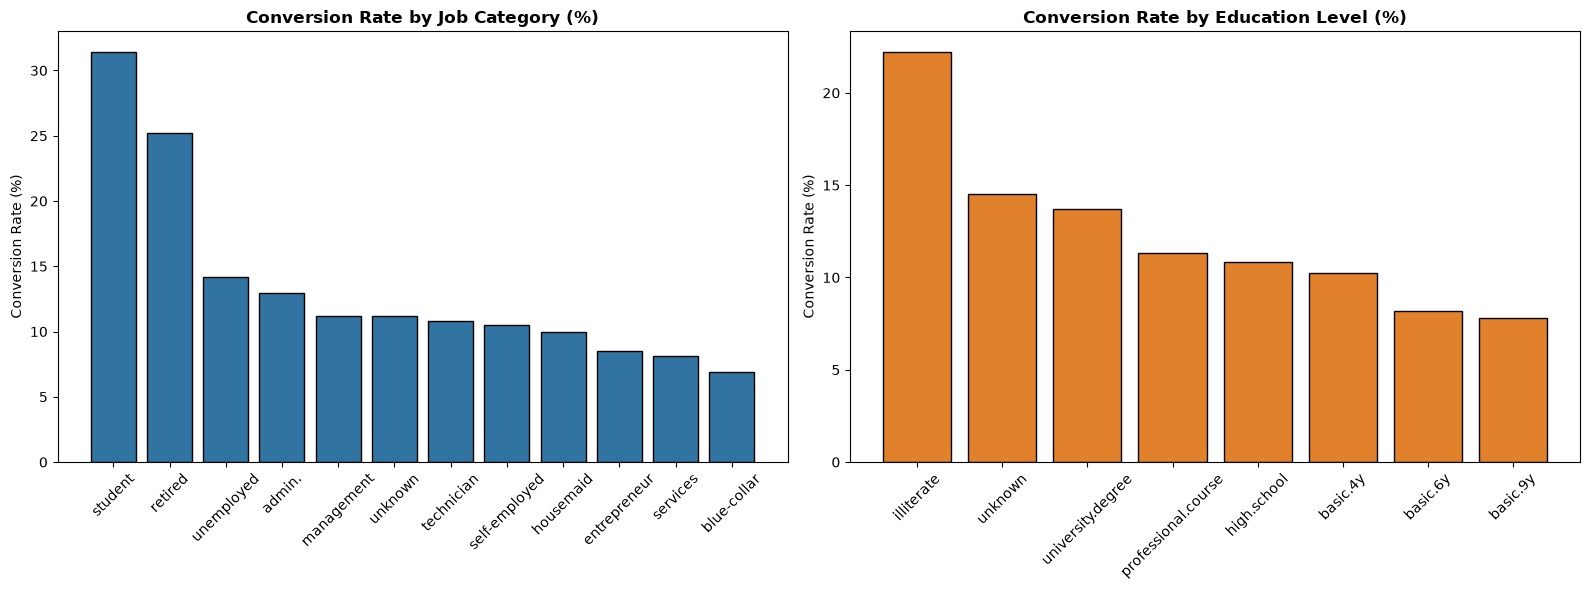

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

job_conv = (
    bank.groupby("job")["y"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .sort_values(ascending=False)
)

# 3. Draw vertical bars for job categories
axes[0].bar(job_conv.index, job_conv.values, color="#3274a1", edgecolor="black")
axes[0].set_title("Conversion Rate by Job Category (%)", fontweight="bold")
axes[0].set_ylabel("Conversion Rate (%)")
axes[0].tick_params(axis="x", rotation=45)

edu_conv = (
    bank.groupby("education")["y"]
    .apply(lambda s: (s == "yes").mean() * 100)
    .sort_values(ascending=False)
)

axes[1].bar(edu_conv.index, edu_conv.values, color="#e1812c", edgecolor="black")
axes[1].set_title("Conversion Rate by Education Level (%)", fontweight="bold")
axes[1].set_ylabel("Conversion Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()